# 1.2 Raw Data Preprocessing

Clean and validate the raw training data, then save the preprocessed train version.

**Steps:**
1. Load the raw train split
2. Apply the preprocessing pipeline
3. Detect and handle outliers
4. Create house_age feature
5. Validate data integrity
6. Save preprocessed train data

> The held-out test split is **not** processed here; notebook 1_6 transforms it with the saved configuration.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1.2.1 Load Raw Data (Train)


In [2]:
RAW_TRAIN_PATH = '../data/data_raw_train.csv'

df_train = pd.read_csv(RAW_TRAIN_PATH)
print(f'Loaded {df_train.shape[0]} train rows and {df_train.shape[1]} columns')
df_train.head()


Loaded 67 train rows and 7 columns


,price,sqft,bedrooms,bathrooms,location,year_built,condition
0,730000,2620,3,2.5,Downtown,1994,Excellent
1,312000,1680,2,1.5,Rural,1959,Fair
2,520000,2050,3,2.0,Urban,1990,Good
3,615000,2230,3,2.0,Downtown,1986,Good
4,398000,1680,2,2.0,Suburb,1968,Fair


## 1.2.2 Shared Preprocessing Pipeline

In [3]:
def detect_outliers_iqr(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper)


def cap_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower, upper)


outlier_cols = ['price', 'sqft']
CURRENT_YEAR = 2026


def preprocess(df):
    df = df.copy()

    initial_rows = len(df)
    df = df.dropna(subset=['price'])
    print(f'Dropped {initial_rows - len(df)} rows with missing price.')

    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
            print(f'Filled {col} missing values with median: {df[col].median():.2f}')

    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])
            print(f'Filled {col} missing values with mode: {df[col].mode()[0]}')

    df['price'] = df['price'].astype(float)
    df['sqft'] = df['sqft'].astype(int)
    df['bedrooms'] = df['bedrooms'].astype(int)
    df['bathrooms'] = df['bathrooms'].astype(float)
    df['year_built'] = df['year_built'].astype(int)

    for col in outlier_cols:
        before = df[col].describe()
        df[col] = cap_outliers(df[col])
        after = df[col].describe()
        print(f'{col}: capped outliers. Range changed from [{before["min"]:.0f}, {before["max"]:.0f}] to [{after["min"]:.0f}, {after["max"]:.0f}]')

    df['house_age'] = CURRENT_YEAR - df['year_built']
    return df


df_train = preprocess(df_train)

print(f'\nRemaining missing values (train): {df_train.isnull().sum().sum()}')


Dropped 0 rows with missing price.
price: capped outliers. Range changed from [251000, 1680000] to [251000, 1257500]
sqft: capped outliers. Range changed from [1380, 3850] to [1380, 3850]

Remaining missing values (train): 0


## 1.2.3 Data Types (Train)

In [4]:
print('Updated dtypes (train):')
print(df_train.dtypes)

Updated dtypes (train):
price         float64
sqft            int64
bedrooms        int64
bathrooms     float64
location       object
year_built      int64
condition      object
house_age       int64
dtype: object


## 1.2.4 Detect and Handle Outliers (Train)

price: 0 outliers detected (0.0%)
sqft: 0 outliers detected (0.0%)


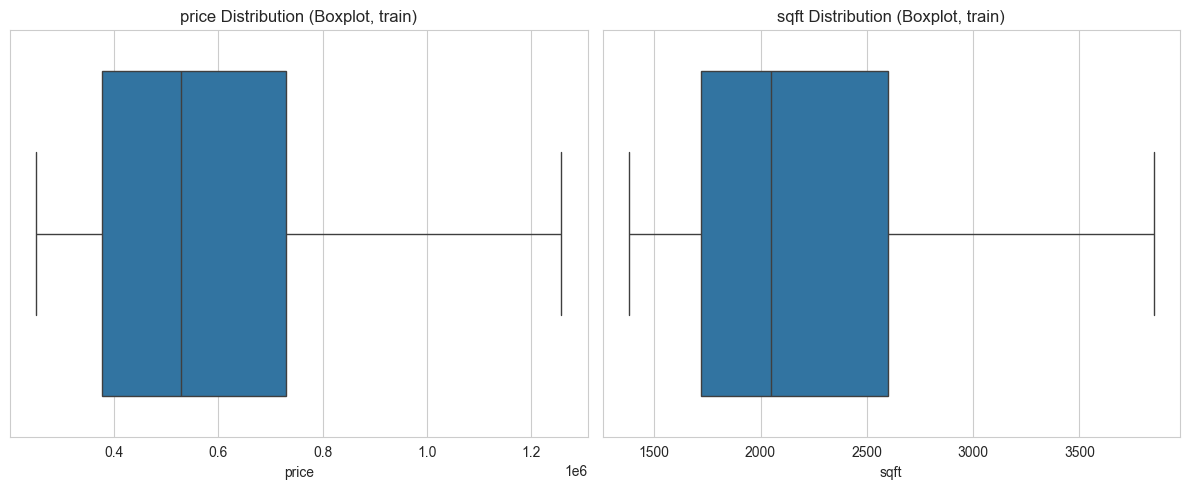

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(outlier_cols):
    outlier_mask = detect_outliers_iqr(df_train[col])
    n_outliers = outlier_mask.sum()
    print(f'{col}: {n_outliers} outliers detected ({n_outliers/len(df_train)*100:.1f}%)')
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(f'{col} Distribution (Boxplot, train)')

plt.tight_layout()
plt.show()

## 1.2.5 Feature: Age of House (Train)

In [6]:
print('house_age statistics (train):')
print(df_train['house_age'].describe())

house_age statistics (train):
count    67.000000
mean     42.641791
std      19.587180
min       7.000000
25%      30.000000
50%      41.000000
75%      59.500000
max      78.000000
Name: house_age, dtype: float64


## 1.2.6 Data Validation (Train)


In [7]:
def validate(df):
    assert df['price'].min() > 0, 'Price has non-positive values!'
    assert df['sqft'].min() > 0, 'Sqft has non-positive values!'
    assert df['bedrooms'].min() >= 0, 'Bedrooms has negative values!'
    assert df['bathrooms'].min() >= 0, 'Bathrooms has negative values!'
    assert df['year_built'].min() >= 1900, 'year_built has suspicious values!'
    assert df['year_built'].max() <= CURRENT_YEAR, 'year_built has future dates!'
    assert df['location'].isin(['Suburb', 'Downtown', 'Rural', 'Waterfront', 'Urban', 'Mountain']).all(), 'Unexpected location values!'
    assert df['condition'].isin(['Poor', 'Fair', 'Good', 'Excellent']).all(), 'Unexpected condition values!'


validate(df_train)
print('All data validation checks passed (train).')


All data validation checks passed (train).


## 1.2.7 Save Preprocessed Data


In [8]:
train_output_path = '../data/data_preprocessed_train.csv'

df_train.to_csv(train_output_path, index=False)

print(f'Saved preprocessed train data to {train_output_path}')
print(f'Train shape: {df_train.shape}')
df_train.head()


Saved preprocessed train data to ../data/data_preprocessed_train.csv
Train shape: (67, 8)


,price,sqft,bedrooms,bathrooms,location,year_built,condition,house_age
0,730000.0,2620,3,2.5,Downtown,1994,Excellent,32
1,312000.0,1680,2,1.5,Rural,1959,Fair,67
2,520000.0,2050,3,2.0,Urban,1990,Good,36
3,615000.0,2230,3,2.0,Downtown,1986,Good,40
4,398000.0,1680,2,2.0,Suburb,1968,Fair,58
